[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanglab-broad/FuseMap/blob/main/docs/notebooks/1_spatial_integration_imaging.ipynb)

In [ ]:
# Running on Google Colab? This cell installs FuseMap (~2 min). Locally it does nothing.
import sys
if "google.colab" in sys.modules:
    !pip install -q fusemap

# FuseMap Tutorial I: Integrating Spatial Transcriptomics Data Across Image-based Technologies

In this tutorial, we'll demonstrate how to use FuseMap to integrate spatial transcriptomics data from different imaging-based technologies (e.g., MERFISH and STARmap). We'll walk through the process step by step, explaining each component in detail.


## 1. Data preparation

We use spatial mouse brain atlases acquired using MERFISH and STARmap as example datasets. The data can be downloaded from:

- MERFISH data: Zhang et al. ([Nature paper](https://www.nature.com/articles/s41586-023-06808-9#data-availability))
- STARmap data: Shi et al. ([Nature paper](https://www.nature.com/articles/s41586-023-06569-5#data-availability))

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import pandas as pd
import scanpy as sc

## 1. Download the example data

Two spatial mouse brain atlases (~740 MB total). STARmap carries author cell-type and
tissue-region annotations (`obs['gt_cell_type_main']`, `obs['gt_tissue_region_main']`);
MERFISH is unannotated — we will transfer labels onto it after integration.

In [2]:
import gdown

os.makedirs("./tutorial1_data", exist_ok=True)
for fid, fname in [("1PUvH3JpGEJ0CrP9DrpIzkH9tIi4VOZ6E", "merfish.h5ad"),
                   ("1jPniIBchuYUPgBdyn16bjt11orsYiSKj", "starmap.h5ad")]:
    if not os.path.exists(f"./tutorial1_data/{fname}"):
        gdown.download(id=fid, output=f"./tutorial1_data/{fname}", quiet=False)

## 2. Integrate — one call

`fusemap.integrate` reads every `.h5ad` in the folder (spatial coordinates are picked up
automatically from `obs['x']/obs['y']`, `obs['col']/obs['row']`, or `obsm['spatial']`),
builds spatial graphs, trains the model, and writes the three universal embeddings.
Re-running the call resumes from the last checkpoint automatically.

The `keep_celltype` / `keep_tissueregion` arguments name existing `obs` label columns to
carry into the output embeddings (cells without labels get `'nan'`).

In [3]:
import fusemap

output_dir = "./output_tutorial1"
fusemap.integrate("./tutorial1_data", output_dir,
                  keep_celltype="gt_cell_type_main",
                  keep_tissueregion="gt_tissue_region_main")

2026-09-09 14:09:31,941 - INFO - Arguments: {'output_save_dir': './output_tutorial1', 'keep_celltype': 'gt_cell_type_main', 'keep_tissueregion': 'gt_tissue_region_main', 'use_llm_gene_embedding': 'false', 'pretrain_model_path': ''}


2026-09-09 14:09:38,973 - INFO - 

---------------------------------- Preprocess adata ----------------------------------



2026-09-09 14:09:47,241 - INFO - 

---------------------------------- Construct graph adata ----------------------------------



2026-09-09 14:09:47,691 - INFO - 

---------------------------------- Process graph adata ----------------------------------



2026-09-09 14:09:48,688 - INFO - 

number of genes in each section:[1104, 1022], Number of all genes: 1701.



...

2026-09-09 14:09:49,380 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=2, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-09 14:09:49,380 - INFO - [FuseMap loader] atlas 0: dense CPU feature cache ENABLED (44954 x 1104 = 0.185 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-09 14:09:49,508 - INFO - [FuseMap loader] atlas 1: dense CPU feature cache ENABLED (43341 x 1022 = 0.165 GB < 2.0 GB limit); per-batch slicing uses torch row indexing.


2026-09-09 14:09:49,627 - INFO - [FuseMap loader] parallel batch preparation ENABLED: num_workers=2, prefetch_factor=4, pin_memory=True, persistent_workers=True.


2026-09-09 14:09:49,633 - INFO - 

---------------------------------- Finish ----------------------------------



## 4. Visualization

### read single-cell embedding

Text(0.5, 1.0, 'Single-cell embedding, colored by sample ID')

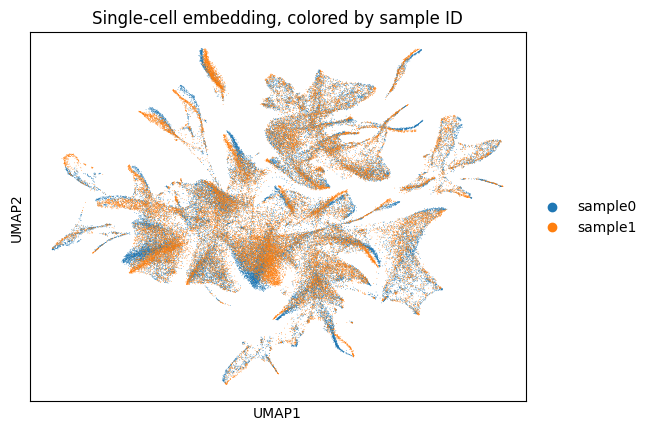

In [4]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_celltype_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='batch',size=1, show=False)
ax.set_title('Single-cell embedding, colored by sample ID')

### read spatial embedding

Text(0.5, 1.0, 'Spatial embedding, colored by sample ID')

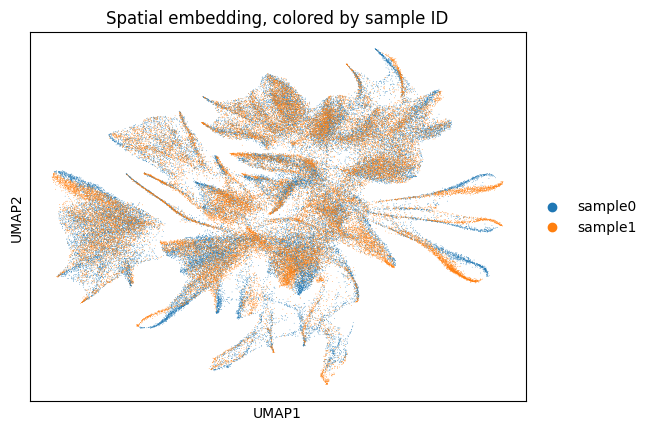

In [5]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_tissueregion_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='batch',size=1, show=False)
ax.set_title('Spatial embedding, colored by sample ID')

### read gene embedding

Text(0.5, 1.0, 'Gene embedding, colored by sample ID')

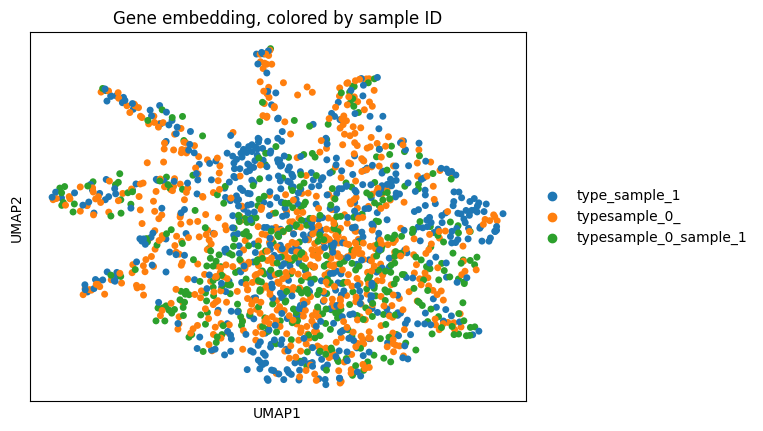

In [6]:
ad_embed=sc.read_h5ad(os.path.join(output_dir, 'ad_gene_embedding.h5ad'))
sc.pp.neighbors(ad_embed, n_neighbors=50,use_rep='X')
sc.tl.umap(ad_embed)
ax = sc.pl.umap(ad_embed,color='type', size=100,show=False)
ax.set_title('Gene embedding, colored by sample ID')

## 5. Transfer cell types (or tissue regions)

In this part, we aim to transfer the cell types from STARmap to merfish. We achieve this by learning a classifier on the cell type embedding space according to the cell type annotations from STARmap. You can modify the `cell_type_index` to tissue region index to transfer tissue region annotations.

## 5. Transfer cell types — one call

STARmap carries expert cell-type labels (`obs['gt_cell_type_main']`); MERFISH does not.
`fusemap.transfer_labels` trains a small classifier on all labeled cells in the shared
embedding and annotates every cell, reporting a balanced held-out accuracy and a per-cell
uncertainty.

In [7]:
ad_cell = sc.read_h5ad(os.path.join(output_dir, "ad_celltype_embedding.h5ad"))

result = fusemap.transfer_labels(ad_cell, label_key="gt_cell_type_main")
print(f"balanced held-out accuracy: {result['test_accuracy']:.3f}")
ad_cell.obs[["gt_cell_type_main", "transfer_gt_cell_type_main"]].head()

balanced held-out accuracy: 0.751


,gt_cell_type_main,transfer_gt_cell_type_main
10001213298420910534616220132541390713,NA,Dentate gyrus granule neurons
100022277878616651012465627153044073802,NA,Telencephalon projecting excitatory neurons
100031110059986866636452231091024948088,NA,Dentate gyrus granule neurons
100047690621461433177092029886904603924,NA,Oligodendrocytes
100048603208029015144240387969442065480,NA,Perivascular macrophages


### Agreement between original and transferred labels

Row-normalized confusion between STARmap's own labels and the transferred labels
(on the labeled cells) — a strong diagonal means the label structure survived the
round-trip through the shared embedding.

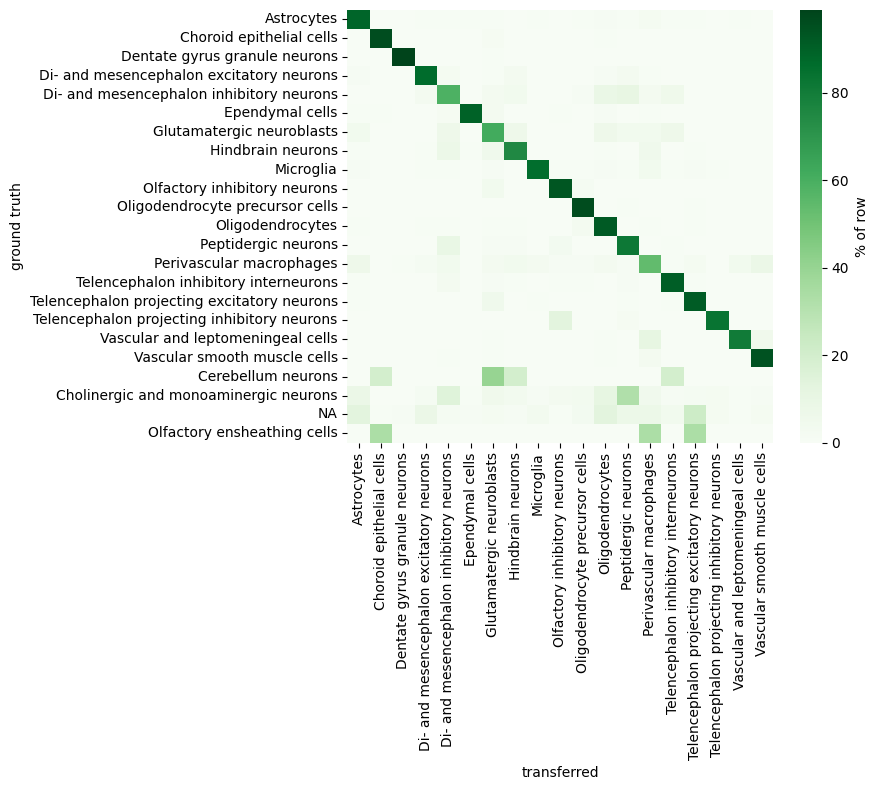

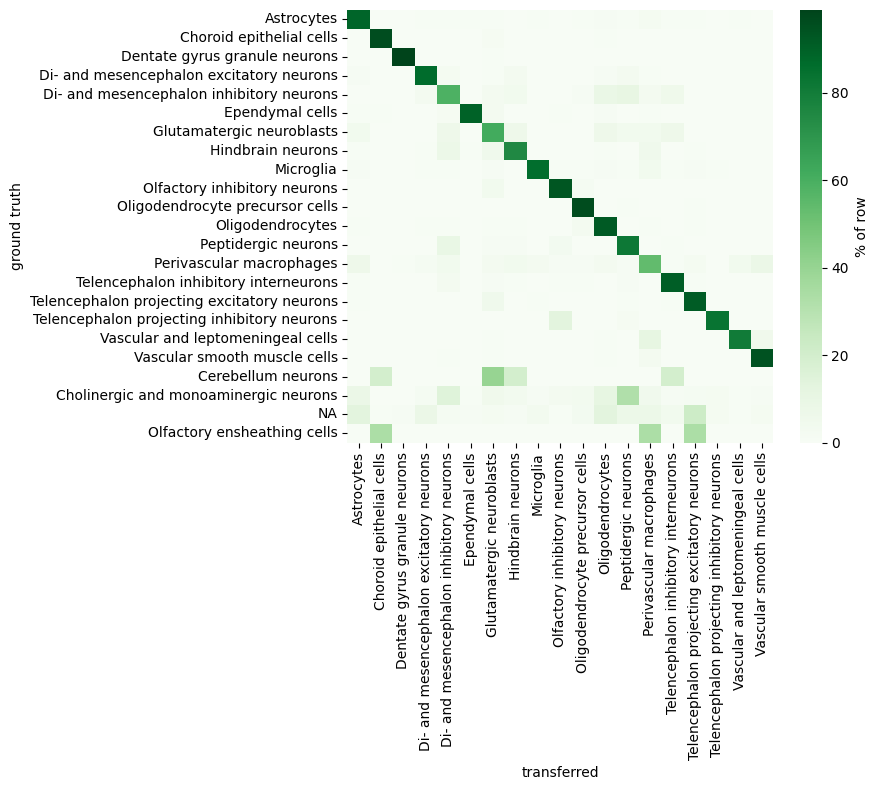

In [8]:
labeled = ~ad_cell.obs["gt_cell_type_main"].astype(str).isin(["nan", "Unannotated"])
fusemap.pl.transfer_heatmap(
    ad_cell.obs.loc[labeled, "gt_cell_type_main"],
    ad_cell.obs.loc[labeled, "transfer_gt_cell_type_main"],
)

### Transferred labels in space

MERFISH cells (which had no labels) now carry cell types; their spatial pattern should
mirror the STARmap reference anatomy.

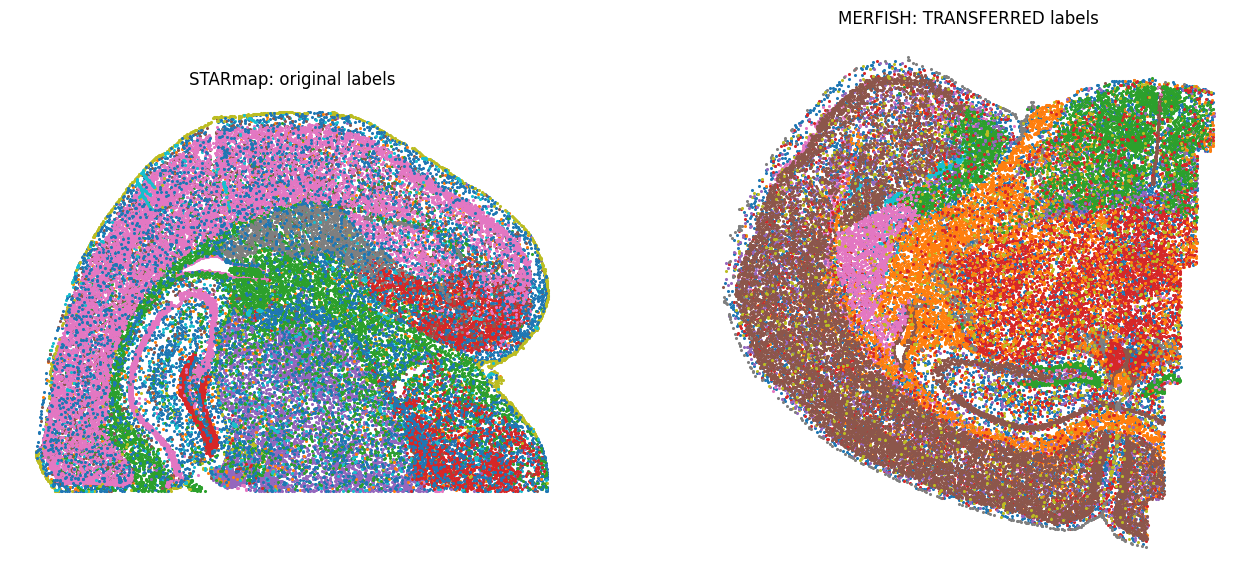

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (batch, title, key) in zip(axes, [
        ("sample1", "STARmap: original labels", "gt_cell_type_main"),
        ("sample0", "MERFISH: TRANSFERRED labels", "transfer_gt_cell_type_main")]):
    sub = ad_cell.obs[ad_cell.obs["batch"] == batch]
    for ct in sorted(sub[key].astype(str).unique()):
        m = sub[key].astype(str) == ct
        if m.sum() > 20:
            ax.scatter(pd.to_numeric(sub["x"][m]), pd.to_numeric(sub["y"][m]), s=1.5, label=None)
    ax.set_title(title); ax.set_aspect("equal"); ax.invert_yaxis(); ax.axis("off")
plt.show()

**Uncertainty**: `ad_cell.obs['transfer_gt_cell_type_main_uncertainty']` flags cells whose
transfer is unreliable (e.g., populations absent from the reference) — filter on it for
downstream analyses. The same call works for tissue regions:
`fusemap.transfer_labels(ad_tissue, label_key="gt_tissue_region_main")`.

## 6. Transfer tissue regions, same recipe

Tissue regions live in the **tissue embedding**. STARmap carries region labels
(`obs['gt_tissue_region_main']`); the transferred labels on MERFISH can be checked against
MERFISH's own independent annotation (`obs['gtTissueRegion']`).


tissue region transfer, balanced held-out accuracy on reference: 0.853


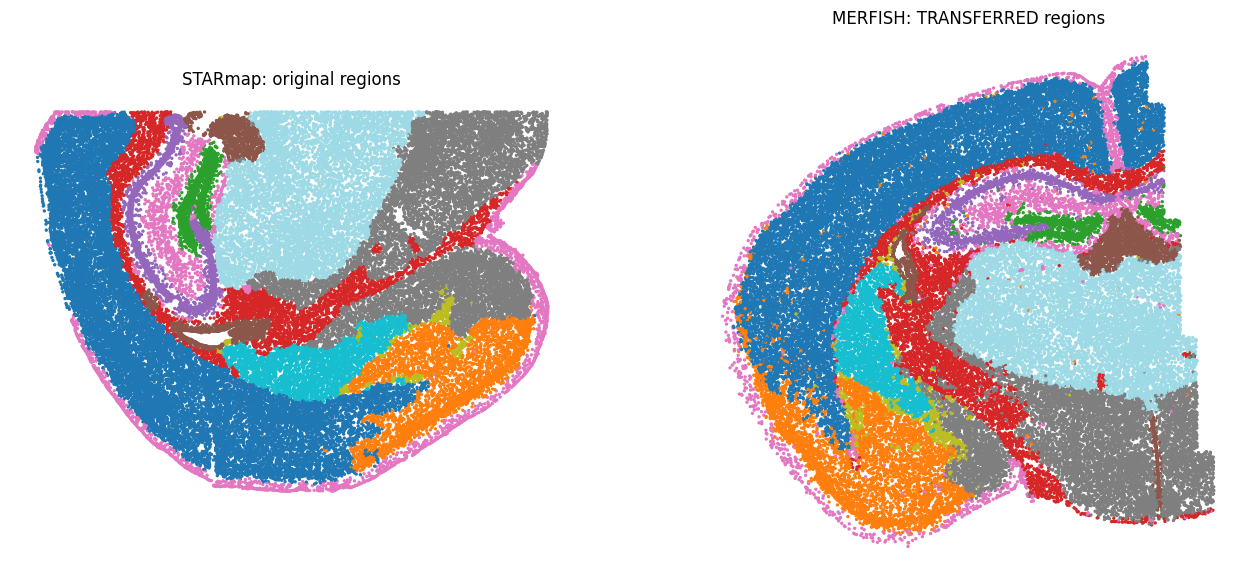

In [10]:
ad_tissue = sc.read_h5ad(os.path.join(output_dir, "ad_tissueregion_embedding.h5ad"))
result_t = fusemap.transfer_labels(ad_tissue, label_key="gt_tissue_region_main")
print("tissue region transfer, balanced held-out accuracy on reference:", round(result_t["test_accuracy"], 3))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (batch, title, key) in zip(axes, [
        ("sample1", "STARmap: original regions", "gt_tissue_region_main"),
        ("sample0", "MERFISH: TRANSFERRED regions", "transfer_gt_tissue_region_main")]):
    sub = ad_tissue.obs[ad_tissue.obs["batch"] == batch]
    codes = pd.Categorical(sub[key].astype(str)).codes
    ax.scatter(pd.to_numeric(sub["x"]), pd.to_numeric(sub["y"]), c=codes, cmap="tab20", s=2)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()

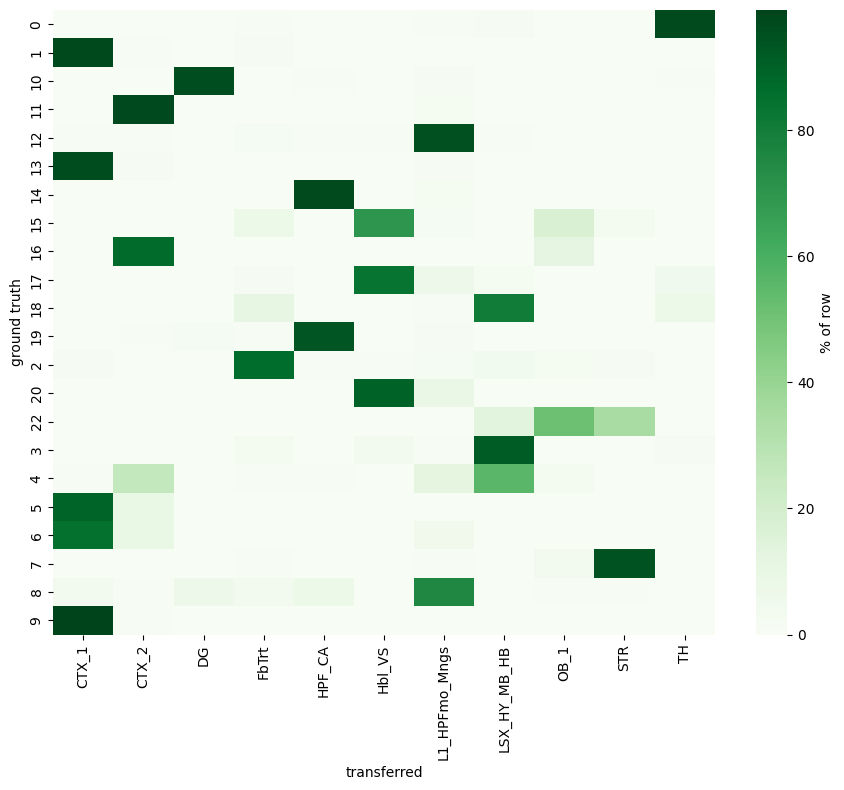

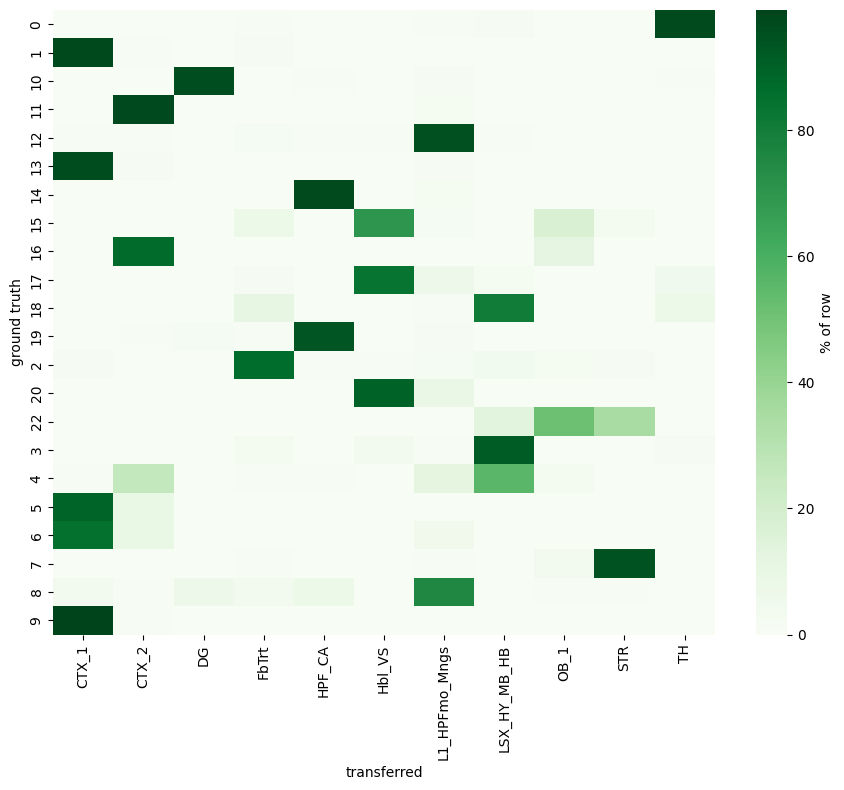

In [11]:
# independent check: MERFISH's own region annotation vs the transferred labels
mer = ad_tissue.obs["batch"] == "sample0"
gt = ad_tissue.obs.loc[mer, "gtTissueRegion"].astype(str)
pred = ad_tissue.obs.loc[mer, "transfer_gt_tissue_region_main"].astype(str)
keep = ~gt.isin(["nan", ""])
fusemap.pl.transfer_heatmap(gt[keep], pred[keep])